In [3]:
def load_data(file_name: str) :
    """"
        Helper functions that extracts the data from the input files.
        The format based on which it extracts can be seen at 'knapsack-20.txt'
        The first line holds the nr of total objects n, then n lines represeting 
        the index, value and weight of the values, then the max_weight is on the last line. 
    Args:
        file_name (str): Input file for extracting data

    Returns:
        int : The total number of objects 
        list[tuple[int, int]]: The results consists of the n tuples(represnting (value, weight) pairs)
        int : The maximum value for the total weight
    """
    weights_and_values = []
    with open(file_name) as f:
        total = int(f.readline())
        for _ in range(total) :
            values = f.readline().split()
            n2 = int(values[1])
            n3 = int(values[2])
            weights_and_values.append((n2, n3))
        
        max_value = int(f.readline())
    
    return total, weights_and_values, max_value

In [4]:
def compute_value_for_solution(solution :list, max_value_weight, weights_values:list[tuple]) :
    """For each solution generated it computes the total value accumulated and
    the weight it reaches , if the weight is valid it return the maximum one, otherwise -1.

    Args:
        solution (list): The list of size n representing the made out of 0s and 1s, representing
        whether the values are added or not.
        max_value_value (int): The maximum weight given as input
        weights_values (list[tuple]) : The input data for all the objects (value, weight) pairs
        
    Returns:
    int : Returns the total value if the weight is lower that the max_value_weight,
            otherwise returns -1
    """
    sum_values = 0
    sum_weights = 0
    
    for i in range(len(solution)) :
        sum_values+=solution[i]*weights_values[i][0]
        sum_weights+=solution[i]*weights_values[i][1]
        
    if sum_weights <= max_value_weight :
        return sum_values
    return -1

In [5]:
import random

def steepest_ascent_hill_climbing(filename: str, n_function_evaluations: int):
    """ We initialzie a global_maxima for the whole search space.
        We initialize a local_maxima for the search space of an instance.
        We initialize a current_hilltop the solution that gets mutated.
        
        Now we generate an initial solution , then check all mutated values with the local_maxima which for each run is,
        at the begining equal to the current_hilltop but gets changed as the mutants are generated. When we finish a 
        search in the local search space we check our solution with the current global maxima and change it found better.
        Implemented also the part where we get more mutants (better mutants) with the same value and we take a random one.
        Also we check for the mutants to be better at least one , otherwise we generate a new instance and update the
        current hilltop and local_maxima accorgingly.After all function evalutaions are done we return the best value found
        both as list of (0,1) and as direct value

    Args:
        filename (str): The filename from which we extract the data for the knapsack problem
        n_function_evaluations (int): This is the count for the number of times the evaluate/fitness funtcion can be called

    Returns:
        max_hilltop_list (list) : The (0,1) best solutuon found structured as a list
        max_hilltop_fitness (int) : The value for the best solution found
    """
    
    size, weights_values, max_weight = load_data(filename)
    
    current_hilltop = list(random.randint(0, 1) for _ in range(size))
    local_hilltop = current_hilltop.copy()
    
    local_hilltop_fitness = compute_value_for_solution(local_hilltop, max_weight, weights_values)
    n_function_evaluations -= 1
    
    max_hilltop_list = current_hilltop.copy()
    max_hilltop_fitness = local_hilltop_fitness
    
    are_all_mutants_worse = False
    
    while n_function_evaluations > 0:
        
        if local_hilltop_fitness > max_hilltop_fitness:
            max_hilltop_list = local_hilltop.copy()
            max_hilltop_fitness = local_hilltop_fitness
        
        if are_all_mutants_worse:
            current_hilltop = list(random.randint(0, 1) for _ in range(size))
            local_hilltop = current_hilltop.copy()
            
            local_hilltop_fitness = compute_value_for_solution(local_hilltop, max_weight, weights_values)
            n_function_evaluations -= 1
            
            if n_function_evaluations <= 0:
                break 
        else:
            current_hilltop = local_hilltop.copy()
            
        are_all_mutants_worse = True
        best_mutants = []  
        
        for i in range(size):
            if n_function_evaluations <= 0:
                break
                
            n_function_evaluations -= 1
            
            current_mutant = current_hilltop.copy()
            current_mutant[i] = 1 - current_mutant[i]
            mutant_fitness = compute_value_for_solution(current_mutant, max_weight, weights_values)
            
            if mutant_fitness > local_hilltop_fitness:
                are_all_mutants_worse = False
                local_hilltop_fitness = mutant_fitness
                best_mutants = [current_mutant.copy()]  
            elif mutant_fitness == local_hilltop_fitness and not are_all_mutants_worse:
                best_mutants.append(current_mutant.copy()) 
        
        if best_mutants:
            local_hilltop = random.choice(best_mutants)  
            
    if local_hilltop_fitness > max_hilltop_fitness:
        max_hilltop_list = local_hilltop.copy()
        max_hilltop_fitness = local_hilltop_fitness

    return max_hilltop_list, max_hilltop_fitness

In [6]:
max_hilltop_list, max_hilltop_fitness = steepest_ascent_hill_climbing("../Lab1Assigment1/knapsack-20.txt", 100)
print(f"List form:{max_hilltop_list}")
print(f"Best value:{max_hilltop_fitness}")

List form:[1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0]
Best value:586


In [13]:
import matplotlib.pyplot as plt

def generate_report(input_file :str, output_file :str, input_value : int) :
    """
        Generates a report of the best value reached for the knapsack problem
        in discussion to the values of n, it then writes the results to a .txt file.
        Also makes a plot having x axis the value of k and y axis the best result obtained to show small increase with n

    Args:
        input_file (str) : Input file for reading, processing data and generating solutions
        output_file (str) : Output file for writting the findings
        input_value (int) : Input value for the number of calls to the SAHC function
    """
    n_vals = [10*i for i in range(input_value)]
    solutions_vals = []
    with open(output_file, 'a') as f :
        f.write(f"\n**Report begining for input value = {input_value}**\n")
    
    for n in n_vals :
        result = steepest_ascent_hill_climbing(input_file, n)
        solutions_vals.append(result[1])
        with open(output_file, "a") as f:
            f.write(f"n(fitness function calls)={n}, best_value={result}\n")
            
    

    plt.plot(n_vals, solutions_vals, marker='o')
    plt.title("Knapsack chart for SAHC")
    plt.xlabel("N-value for the number of fitness calls")
    plt.ylabel("Best solution found")
    plt.grid(True)
    plt.show()
            

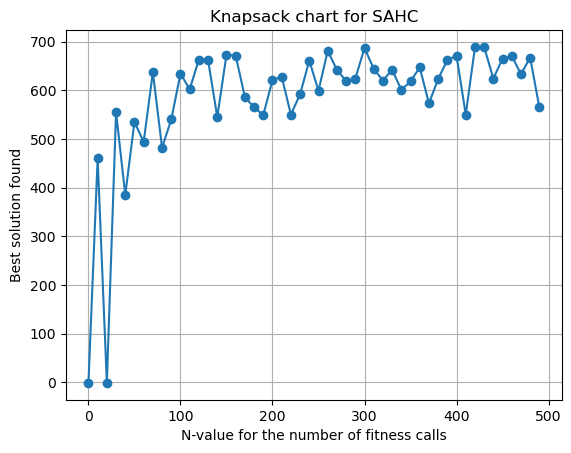

In [17]:
generate_report("../Lab1Assigment1/knapsack-20.txt", 'report_20.txt', 50)

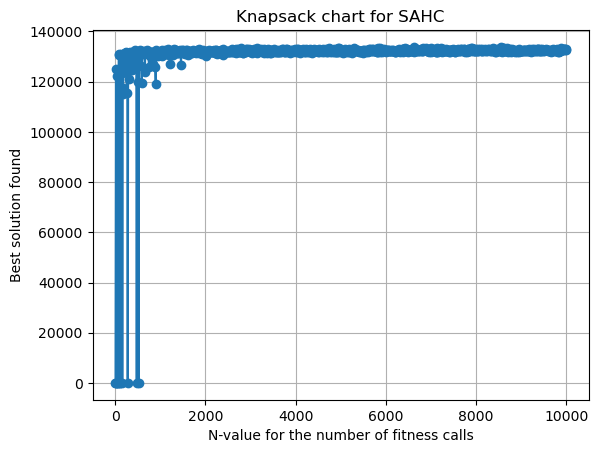

In [18]:
generate_report("../Lab1Assigment1/knapsack-200.txt", 'report_200.txt', 1000)